A parametric model of circumstellar disks 
---
See e.g. section 3.1 in https://ui.adsabs.harvard.edu/abs/2014ApJ...788...59W/abstract

In [28]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import os, sys
import matplotlib
from pathlib import Path
from ruamel.yaml import YAML
from tqdm.auto import tqdm
from gofish import imagecube
from mpl_toolkits.axes_grid1 import make_axes_locatable
import emcee, corner
from collections import OrderedDict
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2'

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte, parametric_disk, inference
from network import shard
from consts import *

In [29]:
def render_cube(projection, disk, nd_co, temperature, velocity_az, bbox, freqs, nu0):
    pixel_area = (projection.fov/projection.npix)**2       # pixel area to convert radiances to Jy 
    ray_coords, obs_dir = sensor.orthographic_disk_projection(projection.npix, projection.nray, projection.incl, projection.phi, projection.posang, 
                                                              projection.fov, projection.r_min, projection.r_max, projection.theta_min, projection.theta_max)
    ray_coords = ray_coords.reshape(projection.npix, projection.npix, projection.nray, 3)
    ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
    ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
    
    # Interpolate dataset along the ray coordinates
    gas_nd = grid.interpolate_scalar(nd_co, ray_coords_polar, bbox)
    gas_t  = grid.interpolate_scalar(temperature, ray_coords_polar, bbox, cval=1e-10)
    gas_v_az = grid.interpolate_scalar(velocity_az, ray_coords_polar, bbox)
    gas_v = parametric_disk.azimuthal_velocity(ray_coords, gas_v_az)
    
    # Einstein coefficient for spontaneous emission from level u to level d
    energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=disk.molecule_table)
    _, a_ud, b_ud, b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions, transition=disk.transition)
    n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, energy_levels, radiative_transitions, transition=disk.transition)

    alpha_tot = line_rte.alpha_total_co(disk.v_turb, gas_t, disk.m_mol)

    print('computing spectral cube for a total of {} frequencies'.format(freqs.size))
    images = line_rte.compute_spectral_cube_pmap(shard(freqs), gas_v, alpha_tot, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area)
    images = np.nan_to_num(images).reshape(projection.linelam, projection.npix, projection.npix)
    return images

def plot_spectral_cube(fig, axes, images, fov, title=None, vmax=None, beamsize=None, cbar_width=0.02):
    if not (beamsize is None):
        x_c = y_c = -.4*fov
        gaussian = sensor.make_gaussian(images.shape[-1], fov_rad, beamsize, beamsize, 0, 1, x_c, y_c)
            
    for ax, image in zip(axes, images):
        im = ax.imshow(image, vmax=vmax, origin='lower')
        if not (beamsize is None):
            cp = ax.contour(gaussian, levels=[0.5*np.max(gaussian)], colors='w', linewidths=1.0)
        ax.axis('off')
    fig.subplots_adjust(left=0.01, wspace=0)
    axes[int(len(axes)/2)-1].set_title(title)
    cax = fig.add_axes([axes[0].get_position().x0, axes[0].get_position().y0-0.05, axes[-1].get_position().x1-axes[0].get_position().x0, cbar_width])
    fig.colorbar(im, cax=cax, location='bottom')


In [30]:
fov_as = 14.0   # arcsecs
num_freqs_resample = 60
data_path = '../data/alma/HD163296_CO_highres_cen.cm.fits'
data_dir = Path(data_path).parent
data_cube = imagecube(data_path, FOV=fov_as)

# resample cube a bit faster than 160 m/s
num_freqs = len(data_cube.freqax)
   
idx = np.round(np.linspace(0, num_freqs-1, num_freqs_resample)).astype(int)

data = data_cube.data[idx]
freqs = data_cube.freqax[idx]
velocities = data_cube.velax[idx]

nu0 = data_cube.nu0
npix = data_cube.nxpix
width_kms = (velocities[-1] - velocities[0]) / 1000.0
delta_v_ms = velocities[1] - velocities[0]
print('velocity resolution: {} m/s'.format(delta_v_ms))
      
# Center the velocities around n0 by removing systemic component
freqs += nu0 - freqs.mean()

velocity resolution: 79.36498855860009 m/s


In [31]:
disk = parametric_disk.DiskFlaherty(
    name='HD163296_CO(2-1)',
    q=-0.27,
    r_c=224.0,
    v_turb=0.31,
    T_atm1=79.0,
    gamma=1.0,
    T_mid1=17.5,
    M_star=2.3*M_sun,
    r_in=9.0,
    M_gas=0.09*M_sun,
    co_abundance=1e-4,
    N_dissoc=0.79*1.59e21,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37*m_h,
    molecule_table='../molecular_tables/molecule_12c16o.inp',
)

resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk.r_in, 800
z_disk, r_disk = jnp.meshgrid(jnp.linspace(z_min, z_max, resolution), jnp.linspace(r_min, r_max, resolution), indexing='ij')

temperature = disk.temperature_profile(z_disk, r_disk)
nd_h2 = parametric_disk.number_density_profile(z_disk, r_disk, temperature, disk.gamma, disk.r_in, disk.r_c, disk.M_gas, disk.M_star, disk.m_mol)
velocity_az = disk.velocity(z_disk, r_disk, nd_h2, temperature)

# Compute the column integrated density N(h2) (units of 1/cm^2)
N_h2 = parametric_disk.surface_density(z_disk, nd_h2)
sigma_h2 = N_h2 * m_h

# Compute the relative abundance of co
abundance_co = disk.co_abundance_profile(N_h2, temperature)
nd_co = abundance_co * nd_h2

distance = 122*pc                         # distance
fov_rad =  fov_as*arcsec                  # field of view 
fov = 2 * distance * np.tan(fov_rad/2.0)  # 1708 [au]
projection = sensor.Projection(
    name=disk.name,
    incl=46.1,
    posang=-312.0,
    npix=npix,
    nray=100,
    phi=0.0,
    fov=fov,
    r_min=10*au,
    r_max=fov/2.0,
    theta_min=0.0,
    theta_max=np.pi,
    linelam=len(freqs),
    width_kms=width_kms,
)
# Bounding box for interpolations
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])

beam = data_cube.beams_per_pix * sensor.make_gaussian(npix, fov_as, data_cube.bmaj, data_cube.bmin, jnp.deg2rad(data_cube.bpa))

# Projection geometry
pixel_area = (projection.fov/projection.npix)**2
ray_coords, obs_dir = sensor.orthographic_disk_projection(
    projection.npix, projection.nray, projection.incl, projection.phi, projection.posang, 
    projection.fov, projection.r_min, projection.r_max, projection.theta_min, projection.theta_max
)
ray_coords = ray_coords.reshape(projection.npix, projection.npix, projection.nray, 3)
ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=disk.molecule_table)

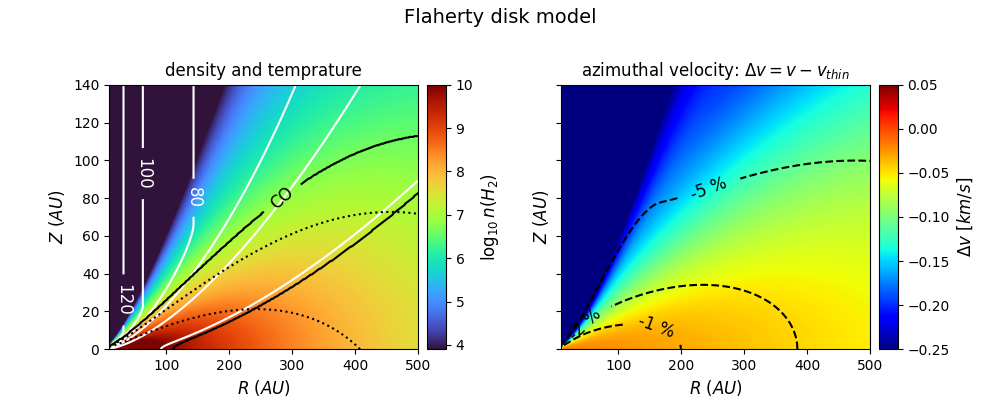

In [5]:
%matplotlib widget
fig, axes = plt.subplots(1,2, figsize=(10,4), sharey=True)
im = axes[0].imshow(np.log10(nd_h2), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);

divider = make_axes_locatable(axes[0])
cax = divider.append_axes('right', size='2%', pad=-3.)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

levels = [20, 40, 60, 80, 100, 120]
cp = axes[0].contour(r_disk, z_disk, temperature, levels, colors='white')
axes[0].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, abundance_co, levels=[5e-5], colors='black')
axes[0].clabel(cp, levels=[5e-5], fmt='CO', inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, sigma_h2, levels=[0.01, 0.1], colors='black', linestyles='dotted')


# Plot azimuthal velocity 
v_thin = np.sqrt(parametric_disk.vsq_keplerian_thin_disk(r_disk, disk.M_star))
delta_v = (velocity_az-v_thin)
im = axes[1].imshow(1e-5*delta_v, cmap='jet', vmin=-0.25, vmax=0.05, origin='lower', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], aspect=3)
divider = make_axes_locatable(axes[1])
cax = divider.append_axes('right', size='2%', pad=-3.)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\Delta v~[km/s]$', fontsize=12)
cp = axes[1].contour(r_disk, z_disk, 100*delta_v/velocity_az, levels=[-5, -2, -1], colors='black')
plt.clabel(cp, [-5, -2, -1], inline=True, fontsize=12, fmt=lambda x:'{:.0f} %'.format(x));

for ax in axes:
    ax.set_xlabel(r'$R~(AU)$', fontsize=12)
    ax.set_ylabel(r'$Z~(AU)$', fontsize=12)
    ax.set_xlim(r_disk.min(),500)
    ax.set_ylim(0,140)

axes[0].set_title('density and temprature')
axes[1].set_title(r'azimuthal velocity: $\Delta v = v-v_{thin}$')
plt.suptitle('Flaherty disk model', fontsize=14, y=0.98);
plt.tight_layout()
fig.subplots_adjust(left=-0.2, wspace=-0.3)

computing spectral cube for a total of 60 frequencies


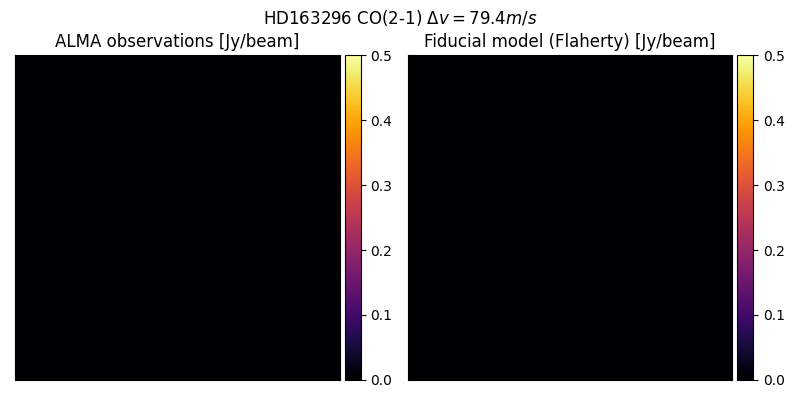

In [48]:
# Render spectral cube and convolve with gaussian beam
images = render_cube(projection, disk, nd_co, temperature, velocity_az, bbox_disk, freqs, nu0)
images_blurred = sensor.fftconvolve_vmap(images, beam)

# Save a gif/plot for the data cube for quick visualization
%matplotlib widget
fig, axes = plt.subplots(1,2,figsize=(8,4))
fig.suptitle(r'HD163296 CO(2-1) $\Delta v = {:2.1f} m/s$'.format(delta_v_ms))
titles = [r'ALMA observations [Jy/beam]', r'Fiducial model (Flaherty) [Jy/beam]']
visualization.animate_movies_synced([data, np.array(images_blurred)], axes, vmin=[0,0], vmax=[0.5]*2, titles=titles, cmaps='inferno', fps=5, output=data_path.replace('fits', 'Flaherty.gif'))

# Parameter inference using `emcee`

In [21]:
posterior_params = OrderedDict(
    q={'bounds': [-np.inf, 0], 'p0_range': [-0.5 ,0]},
    r_c={'bounds': [0, np.inf], 'p0_range': [50 ,300]},
    v_turb={'bounds': [0.0, np.inf], 'p0_range': [0 ,1.0]},
    T_atm1={'bounds': [0, np.inf], 'p0_range': [20 ,150]},
    T_mid1={'bounds': [0, np.inf], 'p0_range': [5 ,40]},
    incl={'bounds': [0, np.pi/2], 'p0_range': [0 ,np.pi/2]}
)

sigma = 5e-3    # 5 mJy is ~1% noise level

# Initialize the sampler
disk_sampler = inference.DiskSampler(
    z_disk, r_disk, bbox_disk, pixel_area, ray_coords, ray_coords_polar, obs_dir, 
    beam, energy_levels, radiative_transitions, sigma, disk, posterior_params
)

ndim, nwalkers = len(posterior_params), 50
p0 = disk_sampler.sample_p0(posterior_params, nwalkers, seed=42)

# Set up the backend
filename = data_dir.joinpath('recovery/{}_mcmc_sampler.h5'.format(disk.name))
backend = emcee.backends.HDFBackend(filename)
backend.reset(nwalkers, ndim)

# Save sampler params to a yaml file
yaml = YAML(typ='safe')
yaml.default_flow_style = False
with open(data_dir.joinpath('recovery/{}_mcmc_params.yaml'.format(disk.name)), 'w') as file:
    yaml.dump(posterior_params, file)

logprob = jax.vmap(disk_sampler.logprob, in_axes=(None, 0, 0))
sampler = emcee.EnsembleSampler(nwalkers, ndim, disk_sampler.logprob, args=[data, freqs], backend=backend)

setting inital seed to: 42


In [52]:
num_iter = 2000
state = sampler.run_mcmc(p0, num_iter, progress=True)

32

In [32]:
sampler_file = '../data/alma/recovery/HD163296_CO(2-1)_mcmc_sampler.h5'
yaml_file = '../data/alma/recovery/HD163296_CO(2-1)_mcmc_params.yaml'
reader = emcee.backends.HDFBackend(sampler_file)

yaml = YAML(typ='safe')
with open(yaml_file, 'r') as stream:
    posterior_params = yaml.load(stream)
param_names = list(posterior_params.keys())

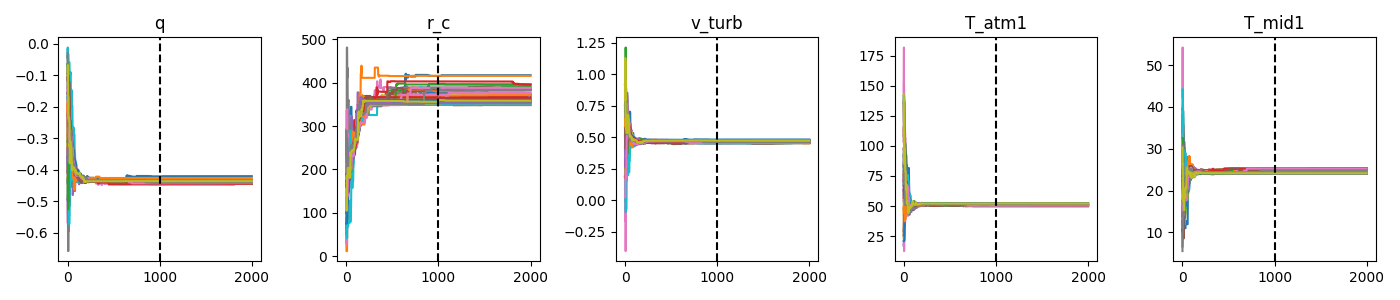

In [34]:
discard = 1000
chain = np.delete(reader.get_chain(), 14, axis=1)
ndim = chain.shape[-1]

%matplotlib widget
fig, axes = plt.subplots(1, ndim, figsize=(14,3))
for i in range(ndim):
    axes[i].plot(chain[...,i])
    axes[i].set_title(param_names[i])
    axes[i].axvline(discard, color='black', linestyle='--')

plt.tight_layout()

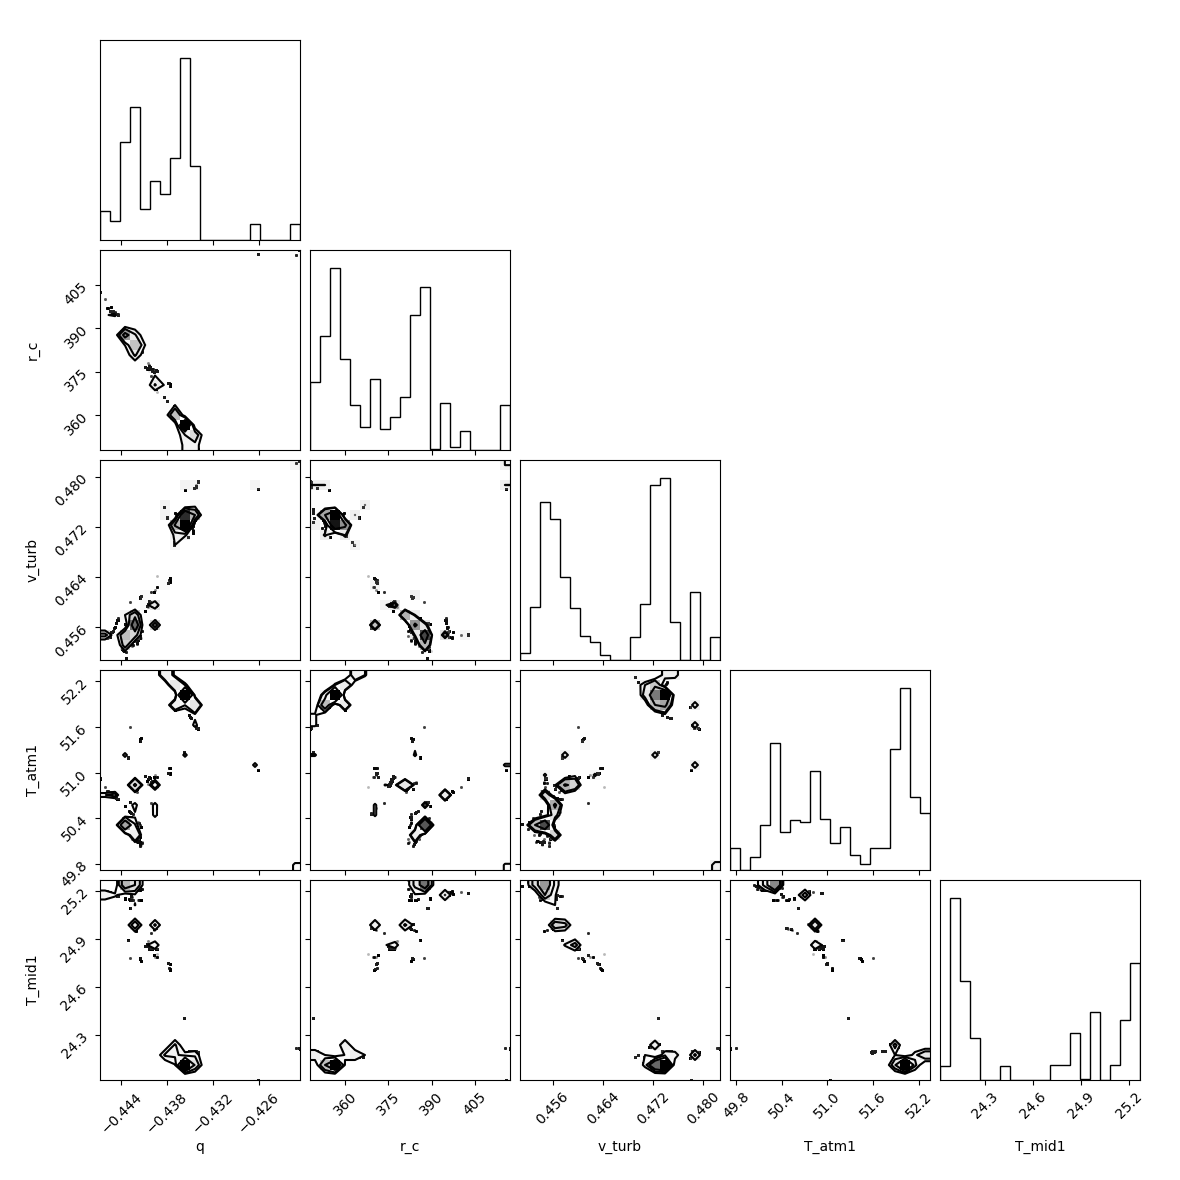

In [35]:
chain = np.delete(reader.get_chain(discard=discard), 14, axis=1)
flat_samples = chain.reshape(-1, ndim)

%matplotlib widget
fig = corner.corner(data=flat_samples, labels=param_names)

In [37]:
from IPython.display import display, Math

print('Uncertainties based on the 16th, 50th, and 84th percentiles of the samples in the marginalized distributions.')
for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], param_names[i])
    display(Math(txt))

Uncertainties based on the 16th, 50th, and 84th percentiles of the samples in the marginalized distributions.


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [32]:
from IPython.display import display, Math

print('Uncertainties based on the 16th, 50th, and 84th percentiles of the samples in the marginalized distributions.')
for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], param_names[i])
    display(Math(txt))

Uncertainties based on the 16th, 50th, and 84th percentiles of the samples in the marginalized distributions.


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Estimated disk from median parameters

In [7]:
disk = parametric_disk.DiskFlaherty(
    name='HD163296_CO(2-1)',
    q=-0.437,
    r_c=366.0,
    v_turb=0.47,
    T_atm1=51.2,
    gamma=1.0,
    T_mid1=24.3,
    M_star=2.3*M_sun,
    r_in=9.0,
    M_gas=0.09*M_sun,
    co_abundance=1e-4,
    N_dissoc=0.79*1.59e21,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37*m_h,
    molecule_table='../molecular_tables/molecule_12c16o.inp',
)

resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk.r_in, 800
z_disk, r_disk = jnp.meshgrid(jnp.linspace(z_min, z_max, resolution), jnp.linspace(r_min, r_max, resolution), indexing='ij')

temperature = disk.temperature_profile(z_disk, r_disk)
nd_h2 = parametric_disk.number_density_profile(z_disk, r_disk, temperature, disk.gamma, disk.r_in, disk.r_c, disk.M_gas, disk.M_star, disk.m_mol)
velocity_az = disk.velocity(z_disk, r_disk, nd_h2, temperature)

# Compute the column integrated density N(h2) (units of 1/cm^2)
N_h2 = parametric_disk.surface_density(z_disk, nd_h2)
sigma_h2 = N_h2 * m_h

# Compute the relative abundance of co
abundance_co = disk.co_abundance_profile(N_h2, temperature)
nd_co = abundance_co * nd_h2

distance = 122*pc                         # distance
fov_rad =  fov_as*arcsec                  # field of view 
fov = 2 * distance * np.tan(fov_rad/2.0)  # 1708 [au]
projection = sensor.Projection(
    name=disk.name,
    incl=46.1,
    posang=-312.0,
    npix=npix,
    nray=100,
    phi=0.0,
    fov=fov,
    r_min=10*au,
    r_max=fov/2.0,
    theta_min=0.0,
    theta_max=np.pi,
    linelam=len(freqs),
    width_kms=width_kms,
)
# Bounding box for interpolations
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])
beam = data_cube.beams_per_pix * sensor.make_gaussian(npix, fov_as, data_cube.bmaj, data_cube.bmin, jnp.deg2rad(data_cube.bpa))

# Projection geometry
pixel_area = (projection.fov/projection.npix)**2
ray_coords, obs_dir = sensor.orthographic_disk_projection(
    projection.npix, projection.nray, projection.incl, projection.phi, projection.posang, 
    projection.fov, projection.r_min, projection.r_max, projection.theta_min, projection.theta_max
)
ray_coords = ray_coords.reshape(projection.npix, projection.npix, projection.nray, 3)
ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=disk.molecule_table)

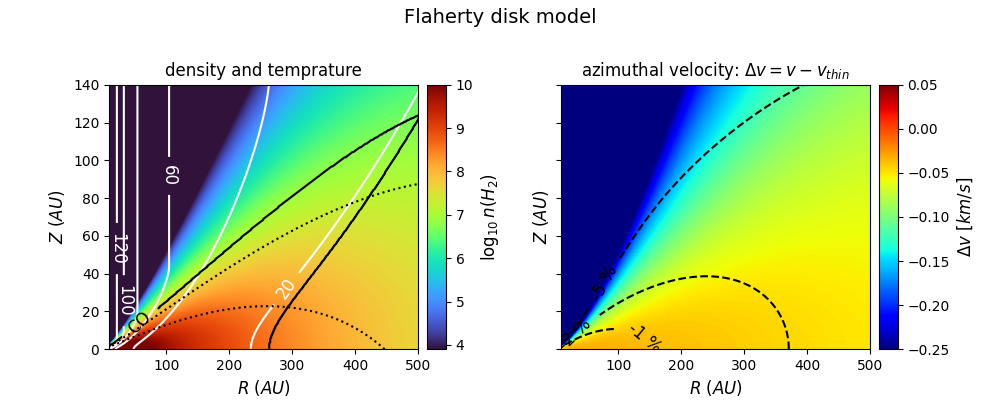

In [8]:
%matplotlib widget
fig, axes = plt.subplots(1,2, figsize=(10,4), sharey=True)
im = axes[0].imshow(np.log10(nd_h2), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);

divider = make_axes_locatable(axes[0])
cax = divider.append_axes('right', size='2%', pad=-3.)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

levels = [20, 40, 60, 80, 100, 120]
cp = axes[0].contour(r_disk, z_disk, temperature, levels, colors='white')
axes[0].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, abundance_co, levels=[5e-5], colors='black')
axes[0].clabel(cp, levels=[5e-5], fmt='CO', inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, sigma_h2, levels=[0.01, 0.1], colors='black', linestyles='dotted')


# Plot azimuthal velocity 
v_thin = np.sqrt(parametric_disk.vsq_keplerian_thin_disk(r_disk, disk.M_star))
delta_v = (velocity_az-v_thin)
im = axes[1].imshow(1e-5*delta_v, cmap='jet', vmin=-0.25, vmax=0.05, origin='lower', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], aspect=3)
divider = make_axes_locatable(axes[1])
cax = divider.append_axes('right', size='2%', pad=-3.)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\Delta v~[km/s]$', fontsize=12)
cp = axes[1].contour(r_disk, z_disk, 100*delta_v/velocity_az, levels=[-5, -2, -1], colors='black')
plt.clabel(cp, [-5, -2, -1], inline=True, fontsize=12, fmt=lambda x:'{:.0f} %'.format(x));

for ax in axes:
    ax.set_xlabel(r'$R~(AU)$', fontsize=12)
    ax.set_ylabel(r'$Z~(AU)$', fontsize=12)
    ax.set_xlim(r_disk.min(),500)
    ax.set_ylim(0,140)

axes[0].set_title('density and temprature')
axes[1].set_title(r'azimuthal velocity: $\Delta v = v-v_{thin}$')
plt.suptitle('Flaherty disk model', fontsize=14, y=0.98);
plt.tight_layout()
fig.subplots_adjust(left=-0.2, wspace=-0.3)

computing spectral cube for a total of 60 frequencies


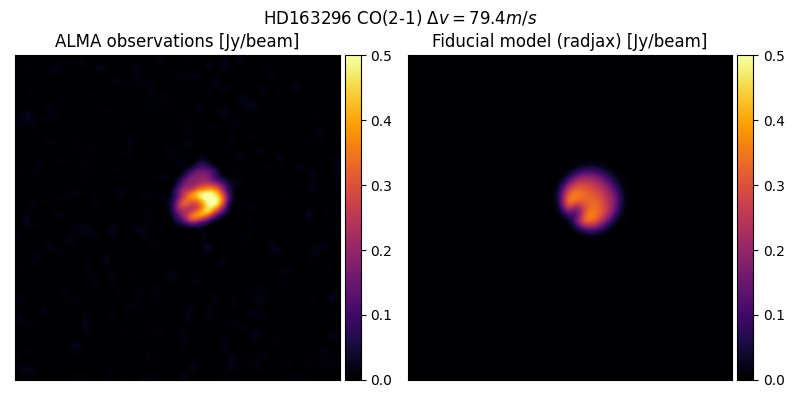

In [38]:
# Render spectral cube and convolve with gaussian beam
images = render_cube(projection, disk, nd_co, temperature, velocity_az, bbox_disk, freqs, nu0)
images_blurred = sensor.fftconvolve_vmap(images, beam)

# Save a gif/plot for the data cube for quick visualization
%matplotlib widget
fig, axes = plt.subplots(1,2,figsize=(8,4))
fig.suptitle(r'HD163296 CO(2-1) $\Delta v = {:2.1f} m/s$'.format(delta_v_ms))
titles = [r'ALMA observations [Jy/beam]', r'Fiducial model (radjax) [Jy/beam]']
visualization.animate_movies_synced([data, np.array(images_blurred)], axes, vmin=[0,0], vmax=[0.5]*2, titles=titles, cmaps='inferno', fps=5, output=data_path.replace('fits', 'radjax.gif'))

In [9]:
# Render spectral cube and convolve with gaussian beam
images_rj = render_cube(projection, disk, nd_co, temperature, velocity_az, bbox_disk, freqs, nu0)
images_blurred_rj = sensor.fftconvolve_vmap(images_rj, beam)

computing spectral cube for a total of 60 frequencies


In [6]:
# Render spectral cube and convolve with gaussian beam
images_fl = render_cube(projection, disk, nd_co, temperature, velocity_az, bbox_disk, freqs, nu0)
images_blurred_fl = sensor.fftconvolve_vmap(images_fl, beam)

computing spectral cube for a total of 60 frequencies


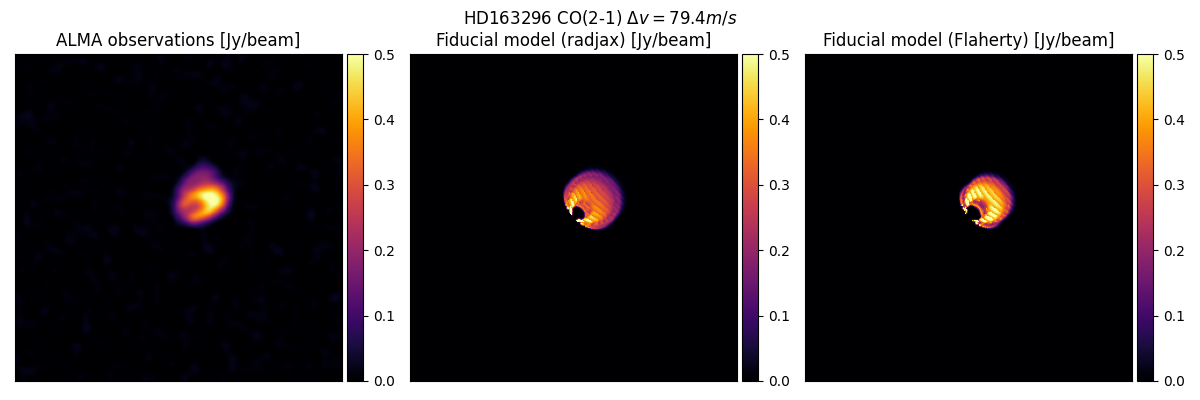

In [11]:
# Save a gif/plot for the data cube for quick visualization
%matplotlib widget
fig, axes = plt.subplots(1,3,figsize=(12,4))
fig.suptitle(r'HD163296 CO(2-1) $\Delta v = {:2.1f} m/s$'.format(delta_v_ms))
titles = [r'ALMA observations [Jy/beam]', r'Fiducial model (radjax) [Jy/beam]', r'Fiducial model (Flaherty) [Jy/beam]']
visualization.animate_movies_synced([data, data_cube.beams_per_pix*np.array(images_rj), data_cube.beams_per_pix*np.array(images_fl)], 
                                    axes, vmin=[0,0,0], vmax=[0.5]*3, titles=titles, cmaps='inferno', fps=5, 
                                    output=data_path.replace('fits', 'radjax_vs_Flaherty_noblur.gif'))

In [25]:
from IPython.display import display, Math
sigma = 5e-3

chi2_fl = np.mean(((images_blurred_fl - data)/sigma)**2)
txt = "\chi^2_{{\mathrm{{Flaherty}}}} = {}"
txt = txt.format(chi2_fl)
display(Math(txt))

chi2_rj = np.mean(((images_blurred_rj - data)/sigma)**2)
txt = "\chi^2_{{\mathrm{{radjax}}}} = {}"
txt = txt.format(chi2_rj)
display(Math(txt))›

<IPython.core.display.Math object>

<IPython.core.display.Math object>